# Pirate Pipeline (V4): The Dtype-Safe Edition

**Final Engineering Patches:**
1. **Physical Categoricals**: Converted string categories to physical integer IDs to eliminate `dtype object` errors.
2. **Numeric-Only Matrix**: Every column is now Float32/Int32, ensuring 100% compatibility with LightGBM/XGBoost.
3. **Flat Hash Join**: Maintains the ultra-stable, list-free candidate filtering logic.


In [7]:
import polars as pl
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import os, gc, warnings, re, optuna
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [8]:
def standardize_age(text):
    if text is None: return -1.0
    ct = str(text).strip().lower()
    dm = {r'\bnb\b': 0, r'\bss\b': 0, r'\bs sơ sinh\b': 0, r'\bs\b': 0.25, r'\bm\b': 0.6, r'\bl\b': 1.2, r'\bxl\b': 2.0, r'\bxxl\b': 3.5}
    for p, v in dm.items():
        if re.search(p, ct): return float(v)
    return -1.0

def load_and_prep(t_path):
    return pl.scan_parquet(t_path).select([
        pl.col('customer_id').cast(pl.Int32),
        pl.col('item_id').cast(pl.Utf8),
        pl.col('updated_date').cast(pl.Datetime).alias('event_ts'),
        pl.col('quantity').cast(pl.Float32).fill_null(0.0),
        pl.col('event_type').cast(pl.Categorical),
        pl.col('price').cast(pl.Float32).fill_null(0.0),
        pl.col('location').cast(pl.Utf8)
    ]).filter((pl.col('event_type')=='purchased')|(pl.col('quantity')>0)).with_columns(pl.col('event_ts').dt.month().cast(pl.Int8).alias('month')).collect()


In [9]:
T_PATH, I_PATH = '/kaggle/input/datasets/kinonquc/qkindataset2/transaction_full_2025.parquet', '/kaggle/input/datasets/kinonquc/qkindataset2/items.parquet'
if not os.path.exists(T_PATH): T_PATH, I_PATH = '../transaction_full_2025.parquet', '../items.parquet'
df_raw = load_and_prep(T_PATH)
items_df = pl.read_parquet(I_PATH).with_columns(pl.col('item_id').cast(pl.Utf8))
items_df = items_df.with_columns(pl.col('size').map_elements(standardize_age, return_dtype=pl.Float32).alias('item_target_age')) if 'size' in items_df.columns else items_df.with_columns(pl.lit(-1.0).alias('item_target_age'))
item_locs = df_raw.group_by('item_id').agg(pl.col('location').unique().alias('item_hubs'))
item_prcs = df_raw.group_by('item_id').agg(pl.col('price').median().alias('item_p'))
df_train_base = df_raw.filter(pl.col('month') <= 10)
df_val_truth  = df_raw.filter(pl.col('month') == 11)
df_train_val_base = df_raw.filter(pl.col('month') <= 11)
df_test_truth = df_raw.filter(pl.col('month') == 12)
del df_raw; gc.collect()


8

In [10]:
class V4Retriever:
    def __init__(self, history_df, items_df, item_locations, item_prices, target_users):
        print("    [Retriever] Initializing Shielded Interactions...")
        self.history_df, self.item_locations, self.item_prices = history_df, item_locations, item_prices
        hist_sampled = history_df.filter(pl.col('customer_id').is_in(pl.Series("customer_id", target_users)))
        ints = hist_sampled.group_by(['customer_id', 'item_id']).agg(pl.col('quantity').sum().alias('w'))
        ints = ints.with_columns([pl.col('customer_id').rank('dense').cast(pl.Int32).alias('u_idx')-1, pl.col('item_id').rank('dense').cast(pl.Int32).alias('i_idx')-1])
        u_map, i_map = ints.select(['customer_id', 'u_idx']).unique(), ints.select(['item_id', 'i_idx']).unique()
        self.u2idx, self.items_list = dict(zip(u_map['customer_id'], u_map['u_idx'])), i_map.sort('i_idx')['item_id'].to_list()
        print(f"    [Retriever] Building Sparse Matrix ({u_map.height} x {i_map.height})...")
        self.matrix = csr_matrix((ints['w'].to_numpy(), (ints['u_idx'].to_numpy(), ints['i_idx'].to_numpy())), shape=(u_map.height, i_map.height), dtype=np.float32)
        del ints, u_map, i_map; gc.collect()
        print("    [Retriever] Computing I2I & SVD...")
        bin_m = self.matrix.copy(); bin_m.data = np.ones_like(bin_m.data); self.i2i = bin_m.T.dot(bin_m).astype(np.float32); self.i2i.setdiag(0)
        del bin_m; gc.collect()
        svd = TruncatedSVD(n_components=64, random_state=42)
        self.u_f, self.i_f = svd.fit_transform(self.matrix).astype(np.float32), svd.components_.T.astype(np.float32)
        print("    [Retriever] Computing Category Profiles...")
        items_cat = items_df.lazy().select(['item_id', 'category_l1']).with_columns(pl.col('category_l1').fill_null('Unk').alias('cat'))
        self.cat_pop = (history_df.lazy().filter(pl.col('month') >= 9).select(['item_id', 'quantity']).join(items_cat, on='item_id', how='left').group_by(['cat', 'item_id']).agg(pl.col('quantity').sum().alias('w')).sort('w', descending=True).group_by('cat').head(30)).collect()
        self.u_t_cat = (hist_sampled.lazy().select(['customer_id', 'item_id']).join(items_cat, on='item_id', how='left').group_by('customer_id').agg(pl.col('cat').mode().first().alias('cat'))).collect()
        del hist_sampled; gc.collect()

    def get_candidates(self, target_users, chunk_size=1000):
        print("    [Retriever] Fetching Repurchases...")
        df_rep = self.history_df.filter(pl.col('customer_id').is_in(pl.Series(target_users))).select(['customer_id', 'item_id']).unique()
        c_i2i, c_svd, i_arr = [], [], np.array(self.items_list)
        t_idx = [self.u2idx[u] for u in target_users if u in self.u2idx]
        t_u = [u for u in target_users if u in self.u2idx]
        for i in range(0, len(t_idx), chunk_size):
            idx, u = t_idx[i:i+chunk_size], np.array(t_u[i:i+chunk_size])
            s_i = self.matrix[idx].dot(self.i2i).toarray(); t40 = np.argsort(-s_i, axis=1)[:, :40]; m = np.take_along_axis(s_i, t40, axis=1) > 0
            c_i2i.append(pl.DataFrame({'customer_id': np.repeat(u, 40)[m.flatten()], 'item_id': i_arr[t40.flatten()][m.flatten()]}, schema={'customer_id': pl.Int32, 'item_id': pl.Utf8}))
            s_s = self.u_f[idx] @ self.i_f.T; t50 = np.argsort(-s_s, axis=1)[:, :50]
            c_svd.append(pl.DataFrame({'customer_id': np.repeat(u, 50), 'item_id': i_arr[t50.flatten()]}, schema={'customer_id': pl.Int32, 'item_id': pl.Utf8}))
            del s_i, s_s, m, t40, t50; gc.collect()
        df_i2i, df_svd = pl.concat(c_i2i).unique() if c_i2i else pl.DataFrame(), pl.concat(c_svd).unique() if c_svd else pl.DataFrame()
        df_cat = self.u_t_cat.filter(pl.col('customer_id').is_in(target_users)).join(self.cat_pop, on='cat').select(['customer_id', 'item_id'])
        return {'rep': df_rep, 'i2i': df_i2i, 'svd': df_svd, 'cat': df_cat}

    def filter_candidates(self, cands_dict, target_users):
        all_cands = pl.concat([df for df in cands_dict.values() if df.height > 0]).unique()
        hist_s = self.history_df.filter(pl.col('customer_id').is_in(pl.Series("customer_id", target_users)))
        uh = hist_s.group_by('customer_id').agg(pl.col('location').mode().first().alias('loc'))
        up = hist_s.group_by('customer_id').agg(pl.col('price').mean().alias('avg_p'))
        del hist_s; gc.collect()
        f = (all_cands.join(up, on='customer_id', how='left').join(self.item_prices, on='item_id', how='left').filter((pl.col('item_p') <= pl.col('avg_p') * 6) | (pl.col('avg_p') == 0)).select(['customer_id', 'item_id']))
        item_loc_flat = self.item_locations.explode('item_hubs').rename({'item_hubs': 'loc'})
        f = (f.join(uh, on='customer_id', how='left').join(item_loc_flat, on=['item_id', 'loc'], how='inner').select(['customer_id', 'item_id']))
        del uh, item_loc_flat; gc.collect()
        return f


In [11]:
def create_dataset_v4(history_df, truth_df, items_df, item_locations, item_prices, sample_users=50000, n_negatives=30):
    target_users = truth_df['customer_id'].unique().to_list()
    if sample_users and sample_users < len(target_users): 
        target_users = list(np.random.choice(target_users, sample_users, replace=False))
        truth_df = truth_df.filter(pl.col('customer_id').is_in(target_users))
    retriever = V4Retriever(history_df, items_df, item_locations, item_prices, target_users)
    cands_dict = retriever.get_candidates(target_users)
    filtered_cands = retriever.filter_candidates(cands_dict, target_users)
    truth = truth_df.select(['customer_id', 'item_id']).unique()
    ds = filtered_cands.join(truth.with_columns(pl.lit(1).cast(pl.Int8).alias('target')), on=['customer_id', 'item_id'], how='left').fill_null(0)
    if n_negatives:
        pos, neg = ds.filter(pl.col('target') == 1), ds.filter(pl.col('target') == 0).with_columns(pl.int_range(0, pl.len()).shuffle(seed=42).alias("_rand")).sort(["customer_id", "_rand"]).group_by("customer_id").head(n_negatives).drop("_rand")
        ds = pl.concat([pos, neg])
    max_ts = history_df['event_ts'].max(); hist_lazy = history_df.lazy()
    mom_lazy = (hist_lazy.select(['item_id', 'event_ts']).group_by('item_id').agg([pl.col('event_ts').filter(pl.col('event_ts') >= max_ts - pl.duration(days=14)).len().alias('rs'), pl.col('event_ts').filter(pl.col('event_ts') < max_ts - pl.duration(days=14)).len().alias('ps')]).with_columns((pl.col('rs')/(pl.col('ps')+1)).alias('item_momentum_ratio')).select(['item_id', 'item_momentum_ratio']))
    item_feats_df = (hist_lazy.select(['item_id', 'quantity', 'customer_id']).group_by('item_id').agg([pl.col('quantity').sum().alias('item_global_vol'), pl.col('customer_id').n_unique().alias('item_unique_buyers')]).join(mom_lazy, on='item_id', how='left')).collect().unique(subset=['item_id'])
    hist_s = history_df.filter(pl.col('customer_id').is_in(pl.Series("customer_id", target_users)))
    user_feats_df = (hist_s.group_by('customer_id').agg([pl.col('item_id').n_unique().alias('user_unique_items'), pl.col('quantity').sum().alias('user_total_volume'), (pl.col('item_id').n_unique() / pl.len()).alias('user_exploration_ratio'), pl.col('price').mean().alias('user_avg_price')]).unique(subset=['customer_id']))
    ui_f = (hist_s.lazy().join(ds.lazy().select(['customer_id', 'item_id']), on=['customer_id', 'item_id'], how='inner').group_by(['customer_id', 'item_id']).agg([pl.col('quantity').sum().alias('ui_buy_vol'), (max_ts - pl.col('event_ts').max()).dt.total_days().cast(pl.Int16).alias('ui_days_since_last_buy')])).collect().unique(subset=['customer_id', 'item_id'])
    del hist_s; gc.collect()
    # DTYPE SAFE: Use physical integer IDs for categorical data to avoid 'dtype object' errors
    return (ds.lazy().join(user_feats_df.lazy(), on='customer_id', how='left').join(item_feats_df.lazy(), on='item_id', how='left').join(ui_f.lazy(), on=['customer_id', 'item_id'], how='left').join(items_df.lazy().select(['item_id', 'category_l1', 'item_target_age']).unique(subset=['item_id']), on='item_id', how='left').with_columns(pl.col('category_l1').fill_null('Unk').cast(pl.Categorical).to_physical().cast(pl.Int32)).fill_null(0)).collect(streaming=True)

print("=== BUILDING DATASETS ===")
train_data = create_dataset_v4(df_train_base, df_val_truth, items_df, item_locs, item_prcs, sample_users=50000)
test_data = create_dataset_v4(df_train_val_base, df_test_truth, items_df, item_locs, item_prcs, sample_users=20000, n_negatives=None)


=== BUILDING DATASETS ===
    [Retriever] Initializing Shielded Interactions...
    [Retriever] Building Sparse Matrix (38284 x 12032)...
    [Retriever] Computing I2I & SVD...
    [Retriever] Computing Category Profiles...
    [Retriever] Fetching Repurchases...
    [Retriever] Initializing Shielded Interactions...
    [Retriever] Building Sparse Matrix (15348 x 10464)...
    [Retriever] Computing I2I & SVD...
    [Retriever] Computing Category Profiles...
    [Retriever] Fetching Repurchases...


In [13]:
feature_cols = ['user_unique_items', 'user_total_volume', 'user_exploration_ratio', 'user_avg_price', 'item_global_vol', 'item_unique_buyers', 'item_momentum_ratio', 'item_target_age', 'ui_buy_vol', 'ui_days_since_last_buy']
all_feats = feature_cols + ['category_l1']

u_tune = train_data['customer_id'].unique().to_list()
u_trn_idx = int(len(u_tune)*0.8)
u_trn, u_val = u_tune[:u_trn_idx], u_tune[u_trn_idx:]
d_trn, d_val = train_data.filter(pl.col('customer_id').is_in(u_trn)), train_data.filter(pl.col('customer_id').is_in(u_val))

def objective(trial):
    params = {'objective': 'binary', 'metric': 'binary_logloss', 'verbosity': -1, 
              'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), 
              'num_leaves': trial.suggest_int('num_leaves', 20, 100)}
    
    # MANUAL NAME-BINDING: Pass numpy + explicit names
    trn_set = lgb.Dataset(d_trn.select(all_feats).to_numpy(), 
                          label=d_trn['target'].to_numpy(), 
                          feature_name=all_feats, 
                          categorical_feature=['category_l1'])
    
    val_set = lgb.Dataset(d_val.select(all_feats).to_numpy(), 
                          label=d_val['target'].to_numpy(), 
                          feature_name=all_feats, 
                          categorical_feature=['category_l1'], 
                          reference=trn_set)
    
    m = lgb.train(params, trn_set, num_boost_round=100, valid_sets=[val_set], 
                  valid_names=['valid'], callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)])
    return m.best_score['valid']['binary_logloss']

print("Running Dtype-Safe Optuna Tuning...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)
best_params = study.best_params; best_params.update({'objective': 'binary', 'metric': 'binary_logloss'})
print("Best Params (Safe):", best_params)


Running Dtype-Safe Optuna Tuning...
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's binary_logloss: 0.139332
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's binary_logloss: 0.13903
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's binary_logloss: 0.139184
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's binary_logloss: 0.139207
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's binary_logloss: 0.13893
Best Params (Safe): {'learning_rate': 0.06947157418244752, 'num_leaves': 78, 'objective': 'binary', 'metric': 'binary_logloss'}


Training Final Models...


<Figure size 1000x600 with 0 Axes>

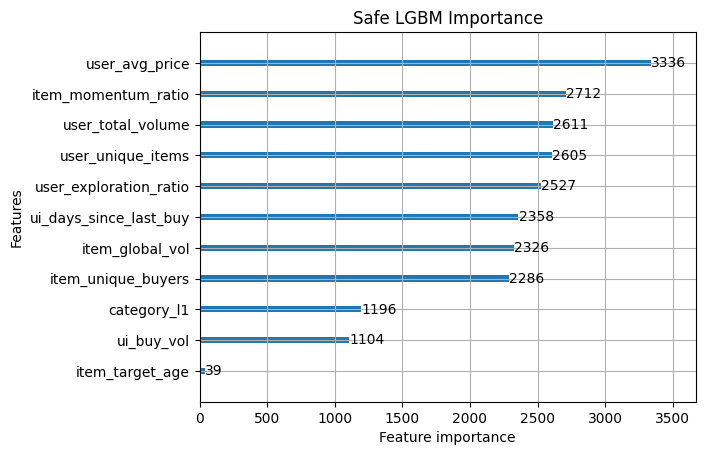

In [15]:
from catboost import Pool
print("Training Final Models...")

# LightGBM (Stays the same, name-binding fix works)
lgb_m = lgb.train(best_params, 
                  lgb.Dataset(train_data.select(all_feats).to_numpy(), 
                              label=train_data['target'].to_numpy(), 
                              feature_name=all_feats, 
                              categorical_feature=['category_l1']), 
                  num_boost_round=300)

# XGBoost (Stays the same, handles the float-cast category fine)
xgb_m = xgb.XGBClassifier(n_estimators=200, learning_rate=best_params.get('learning_rate', 0.05), 
                          enable_categorical=True).fit(train_data.select(all_feats).to_numpy(), train_data['target'].to_numpy())

# CatBoost (SWITCH TO POOL: Handles the Polars Int32 categories perfectly)
train_pool = Pool(train_data.select(all_feats), label=train_data['target'], cat_features=['category_l1'])
cb_m = CatBoostClassifier(iterations=200, verbose=0).fit(train_pool)

plt.figure(figsize=(10, 6)); lgb.plot_importance(lgb_m, max_num_features=15, title='Safe LGBM Importance'); plt.show()


In [16]:
test_data = test_data.with_columns([pl.Series(name='pred_lgb', values=lgb_m.predict(test_data.select(all_feats))), pl.Series(name='pred_xgb', values=xgb_m.predict_proba(test_data.select(all_feats))[:, 1]), pl.Series(name='pred_cb', values=cb_m.predict_proba(test_data.select(all_feats))[:, 1])])
def evaluate_model(model_col):
    top10 = test_data.sort(['customer_id', model_col], descending=[False, True]).group_by('customer_id', maintain_order=True).head(10)
    truth_map = df_test_truth.filter(pl.col('customer_id').is_in(top10['customer_id'].unique().to_list())).group_by('customer_id').agg(pl.col('item_id'))
    truth_dict, pred_dict = {row[0]: set(row[1]) for row in truth_map.iter_rows()}, {row[0]: list(row[1]) for row in top10.group_by('customer_id').agg(pl.col('item_id')).iter_rows()}
    h, m, p = 0, 0.0, 0.0
    for uid, truth in truth_dict.items():
        preds = pred_dict.get(uid, [])
        hits = [pr for pr in preds if pr in truth]
        h += len(hits); p += len(hits)/10.0
        for i, pr in enumerate(preds):
            if pr in truth: m += 1.0/(i+1); break
    return {'Hits': h, 'Precision@10': p/max(1,len(truth_dict)), 'MRR': m/max(1,len(truth_dict))}
print("=== Safe LGBM ==="); print(evaluate_model('pred_lgb'))
print("=== Safe XGBoost ==="); print(evaluate_model('pred_xgb'))
print("=== Safe CatBoost ==="); print(evaluate_model('pred_cb'))


=== Safe LGBM ===
{'Hits': 16563, 'Precision@10': 0.10791634089131501, 'MRR': 0.4582103660680631}
=== Safe XGBoost ===
{'Hits': 16497, 'Precision@10': 0.10748631743549011, 'MRR': 0.4533399212347574}
=== Safe CatBoost ===
{'Hits': 16212, 'Precision@10': 0.1056293979671558, 'MRR': 0.44224608138798505}
